# Project data exploration II -
## plotting categorical plot and incorporating other data

---


We will continue to work with the dataset that your group is consider for the term project. In this notebook we will create some plot using the Seaborn module and the different categorical plots we practiced in class. Additionally, we will explore the idea of working with other datasets in addition to the one you originally selected to strengthen your argument.

Group name:DGIM  
Created by Grant Biellak, Duc Nguyen, Ido Belyaev, Michael Hamaty
Last updated: March 27th


### Q1: How clean is your data?  
Do you have formatting concerns, null values, inconsistent data, etc... If so, explain what cleaning or reformating you have to do and how you plan to approach this cleaning steps.

In [2]:
from datasets import load_dataset
import pandas as pd
dataset = load_dataset("electricsheepafrica/nigerian-banking-bnpl")
df = dataset["train"].to_pandas()


# 1. Null values
print("=== Null values per column ===")
print(df.isnull().sum())

# 2. Rows with ANY null
print(f"\nTotal rows with at least one null: {df.isnull().any(axis=1).sum()}")

# 3. Suspicious zeros in interest_rate_monthly
zero_interest = (df["interest_rate_monthly"] == 0).sum()
print(f"\nRows where interest_rate_monthly == 0: {zero_interest}")
print(f"  ({round(zero_interest / len(df) * 100, 2)}% of data)")

# 4. Date columns — currently strings, need conversion
print("\n=== Column dtypes ===")
print(df.dtypes)

# 5. Quick stats on key numeric columns
print("\n=== Key column stats ===")
df[["principal_ngn", "interest_rate_monthly", "credit_score", "num_installments"]].describe()

=== Null values per column ===
transaction_id           0
purchase_date            0
customer_id              0
merchant_category        0
merchant_name            0
customer_state           0
principal_ngn            0
interest_rate_monthly    0
tenor_days               0
num_installments         0
provider                 0
credit_score             0
first_time_customer      0
first_payment_due        0
default_30d              0
default_90d              0
dtype: int64

Total rows with at least one null: 0

Rows where interest_rate_monthly == 0: 600377
  (30.02% of data)

=== Column dtypes ===
transaction_id                   object
purchase_date            datetime64[ns]
customer_id                      object
merchant_category                object
merchant_name                    object
customer_state                   object
principal_ngn                   float64
interest_rate_monthly           float64
tenor_days                        int64
num_installments                  int

,principal_ngn,interest_rate_monthly,credit_score,num_installments
count,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,4.997801e+04,2.624833e-02,6.195104e+02,1.450168e+00
std,4.653320e+04,1.821959e-02,8.475805e+01,6.689066e-01
min,5.000000e+03,0.000000e+00,3.000000e+02,1.000000e+00
25%,2.115587e+04,0.000000e+00,5.620000e+02,1.000000e+00
50%,3.631706e+04,3.214986e-02,6.200000e+02,1.000000e+00
75%,6.230851e+04,4.107198e-02,6.770000e+02,2.000000e+00
max,5.000000e+05,5.000000e-02,8.500000e+02,3.000000e+00


Our dataset turned out to be pretty clean overall. The first thing we checked was null values, and surprisingly there were none across all 2 million rows, so we don't need to worry about dropping any rows for missing data.

One thing that stood out was that about 30% of the rows (600,377) have an interest_rate_monthly of 0. At first this seemed like bad data, but it actually makes sense since a lot of BNPL deals in are advertised as interest-free, so these are probably legitimate transactions. We plan to keep these rows and add a flag column to mark them as interest-free, since that could be a useful feature for our ML model.

We also noticed that purchase_date and first_payment_due were already parsed as datetime objects by the time we loaded the data, so no conversion was needed there.

The main cleaning we still need to do is encoding the categorical columns like merchant_category, provider, and customer_state before we can feed them into any ML model. We also want to scale principal_ngn since the loan amounts vary a lot and that could throw off certain models.

### Q2: Create a categorical plot
Come up with a unique question that can be answer using a categorical plot from the sns module

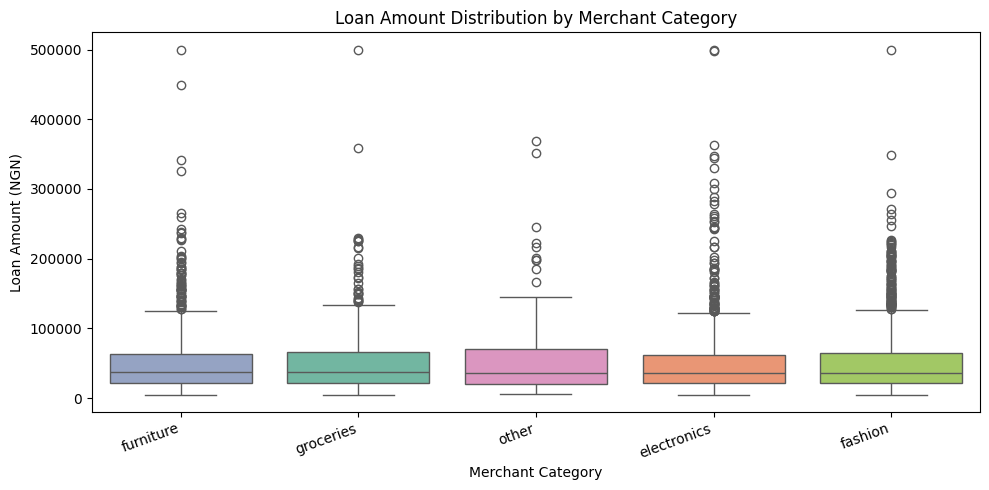

In [5]:
# Your code here . . .
import seaborn as sns
import matplotlib.pyplot as plt

# Question: How do loan amounts differ across merchant categories?
df_sample = df.sample(5000, random_state=42)

order = (
    df_sample.groupby("merchant_category")["principal_ngn"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_sample,
    x="merchant_category",
    y="principal_ngn",
    hue="merchant_category",
    order=order,
    palette="Set2",
    legend=False
)

plt.title("Loan Amount Distribution by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Loan Amount (NGN)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Looking at the boxplot, all five merchant categories have pretty similar median loan amounts, sitting around 40,000–50,000 NGN. That was a bit surprising — we expected electronics and furniture to be noticeably higher since those are bigger purchases. What does stand out though is the spread and outliers. Every category has loans going all the way up to 500,000 NGN, which tells us that regardless of what someone is buying, some customers are taking out very large BNPL loans. The "other" category has a slightly higher median and wider interquartile range, which makes sense since it's a catch-all for purchases that don't fit neatly into the other groups. Overall, merchant category alone might not be the strongest predictor of loan size, but it's still worth including as a feature in our ML model.

### Q3: Come up with a another unique question. This question must use map() or apply()

        credit_tier  default_rate_pct
0       Poor (<580)             19.68
1    Fair (580-669)              4.29
2    Good (670-739)              0.02
3  Excellent (740+)              0.02


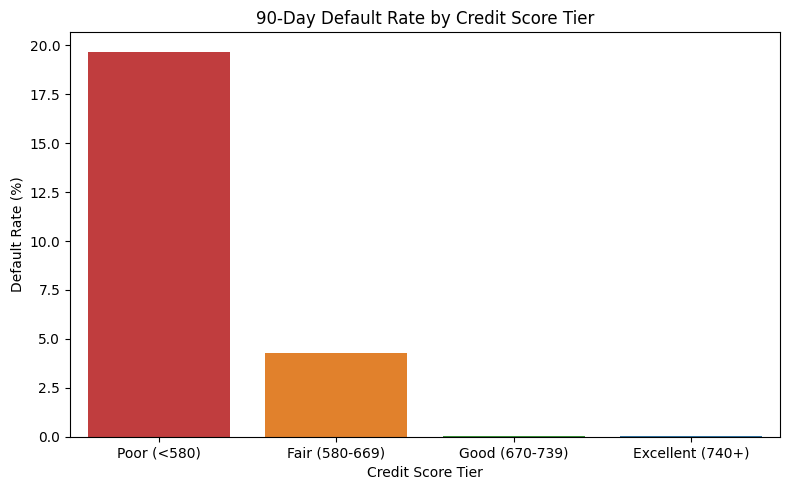

In [6]:
# Your code here . . .
#Question: Do customers with different credit score tiers have different default rates?
# use apply() to bin credit scores into tiers
def assign_credit_tier(score):
    if score < 580:
        return "Poor (<580)"
    elif score < 670:
        return "Fair (580-669)"
    elif score < 740:
        return "Good (670-739)"
    else:
        return "Excellent (740+)"

df["credit_tier"] = df["credit_score"].apply(assign_credit_tier)

# calculate default rate per tier
tier_order = ["Poor (<580)", "Fair (580-669)", "Good (670-739)", "Excellent (740+)"]

tier_defaults = (
    df.groupby("credit_tier")["default_90d"]
    .mean()
    .reindex(tier_order)
    .reset_index()
)
tier_defaults["default_rate_pct"] = (tier_defaults["default_90d"] * 100).round(2)

print(tier_defaults[["credit_tier", "default_rate_pct"]])

plt.figure(figsize=(8, 5))
sns.barplot(
    data=tier_defaults,
    x="credit_tier",
    y="default_rate_pct",
    hue="credit_tier",
    order=tier_order,
    palette=["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"],
    legend=False
)

plt.title("90-Day Default Rate by Credit Score Tier")
plt.xlabel("Credit Score Tier")
plt.ylabel("Default Rate (%)")
plt.tight_layout()
plt.show()

We used apply() to create a new credit_tier column by bucketing raw credit scores into four categories — Poor, Fair, Good, and Excellent — and then plotted the average 90-day default rate for each group.

The difference is dramatic. Customers in the Poor tier (credit score below 580) default at nearly 20%, while Fair customers are around 4.3%, and anyone with a Good or Excellent score defaults at basically 0%. This tells us that credit score is by far the strongest signal in our dataset for predicting whether someone will repay their loan. It also validates the approach from our proposal — building a model around credit score makes a lot of sense. The credit_tier column we created here could itself be a useful engineered feature to include alongside the raw score in our ML pipeline.

### Q4: Create an interactive plot
Create an interactive plot using plotly. Your plot can be a previously asked question or a new question, however explain how this interaction strengthen what you want to communicate with your audience.

In [8]:
# Your code here . . .
#Question: How do credit score and loan amount relate to default risk?
import plotly.express as px

df_plot = df.sample(3000, random_state=42).copy()

# cast to bool first to handle any dtype, then map to labels
df_plot["Default Status"] = df_plot["default_90d"].astype(bool).map(
    {False: "Paid on Time", True: "Defaulted"}
)

fig = px.scatter(
    df_plot,
    x="credit_score",
    y="principal_ngn",
    color="Default Status",
    color_discrete_map={
        "Paid on Time": "#2ca02c",
        "Defaulted":    "#d62728"
    },
    hover_data=["merchant_category", "provider", "num_installments", "credit_tier"],
    opacity=0.5,
    title="Credit Score vs Loan Amount colored by Default Status",
    labels={
        "credit_score":  "Credit Score",
        "principal_ngn": "Loan Amount (NGN)"
    },
    height=550
)

fig.update_layout(legend_title_text="Repayment Status")
fig.show()

fig.write_html("bnpl_interactive.html")
print("Saved to bnpl_interactive.html")

Saved to bnpl_interactive.html


We made this plot interactive because with 2 million rows, a static scatter plot would just be one giant blob of points with no way to explore the data. By using Plotly, our audience can hover over any individual point to see that transaction's credit score, loan amount, merchant category, provider, number of installments, and credit tier all at once.

The pattern this reveals is really clear — red dots (defaulted customers) are heavily concentrated on the left side of the chart where credit scores are below 600, and they almost completely disappear once you get past a score of 650 or so. The right side of the chart is almost entirely green. This visually confirms what we found in Q3, but in a much more compelling way since you can interact with it and zoom into the high-density areas around the 550–650 credit score range where the most defaults are happening.

## Q5: Additional datasets and data processing
For the questions below you do not need to do the plotting if you have not found another complementary dataset. However, write the psuedocode of how you could go about answering the questions and sketches of what your visualization might be. Answer the following:

What additional datasets would you need to find or create to help strengthen your data?
How would you combine the dataset?
Do you need to reshape your data and how could you go about it?

A dataset that would really help us is Nigeria's monthly macroeconomic indicators — things like inflation rate and unemployment. We'd expect that when the economy is struggling, more people default, and being able to show that connection would strengthen our argument a lot. A second useful addition would be more customer demographics like age and employment type, since those seem like they'd matter for predicting repayment.

To combine the macro data we'd extract a year_month from our purchase_date column and do a left join with the macro dataset on that key. For the demographic data we'd join on customer_id.

For reshaping, the main thing we'd need to do is one-hot encode our categorical columns like merchant_category and provider before feeding the data into any ML model. The macro data might also need to be melted from wide to long format before merging.

In [ ]:
# Your code here . . .

# join macro data on year_month
# df['year_month'] = df['purchase_date'].dt.to_period('M')
# macro_df['year_month'] = pd.to_datetime(macro_df['date']).dt.to_period('M')
# df_merged = pd.merge(df, macro_df[['year_month', 'inflation_rate']],
#                      on='year_month', how='left')

# join demographic data on customer_id
# df_merged = pd.merge(df_merged, demo_df, on='customer_id', how='left')

# one-hot encode categoricals for ML
# df_encoded = pd.get_dummies(df_merged,
#                  columns=['merchant_category', 'provider', 'customer_state'])

# sketch: dual-axis line chart
# left y-axis  = monthly default rate
# right y-axis = nigeria inflation rate
# hypothesis: default rate rises when inflation spikes

# fig, ax1 = plt.subplots(figsize=(12, 5))
# ax2 = ax1.twinx()
# ax1.plot(monthly['year_month'], monthly['default_rate'], color='red',  label='Default Rate')
# ax2.plot(monthly['year_month'], monthly['inflation'],    color='blue', label='Inflation Rate')
# plt.title('Monthly Default Rate vs Nigeria Inflation Rate')
# plt.show()